# WatcherML demo: real CUDA OOM → verified recovery on Google Colab

This notebook runs WatcherML's complete v1 workflow with:

- the real CIFAR-10 dataset;
- a real PyTorch ResNet-18 training loop;
- a **genuine CUDA allocator out-of-memory error** raised inside the model forward pass;
- a deterministic WatcherML failure capsule;
- a zero-compute recovery plan;
- policy-bounded interventions;
- fresh subprocess probes and full trials;
- constraint-first ranking;
- two independent confirmation runs;
- campaign tables, verification evidence, and VRAM visualizations.

The model includes a documented adaptive activation-pressure layer so the demonstration
produces a real OOM reliably across different Colab GPU sizes. The exception is not
mocked or manually raised: PyTorch's CUDA allocator genuinely refuses an allocation.
Reducing `batch_size` reduces the pressure proportionally, allowing WatcherML's bounded
intervention policy to recover the workload.

**Expected runtime:** approximately 8–20 minutes. **Tested on T4**

In [1]:
import os
import platform
import subprocess
import sys

subprocess.run(["nvidia-smi"], check=True)

import torch

assert torch.cuda.is_available(), (
    "CUDA is unavailable. In Colab choose Runtime → Change runtime type → GPU."
)

GPU_NAME = torch.cuda.get_device_name(0)
FREE_BYTES, TOTAL_BYTES = torch.cuda.mem_get_info()

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", GPU_NAME)
print(f"VRAM free/total: {FREE_BYTES / 2**30:.2f} / {TOTAL_BYTES / 2**30:.2f} GiB")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA runtime: 12.8
GPU: Tesla T4
VRAM free/total: 14.46 / 14.56 GiB


## 1. Install WatcherML



In [5]:
INSTALL_MODE = "github"  # "github", "pypi", or "wheel"
GITHUB_REF = "release/v0.1.0"

if INSTALL_MODE == "github":
    install_spec = (
        "git+https://github.com/Rohan5manza/WatcherML.git@" + GITHUB_REF
    )
elif INSTALL_MODE == "pypi":
    install_spec = "watcherml==0.1.0"
elif INSTALL_MODE == "wheel":
    from google.colab import files

    uploaded = files.upload()
    wheel_names = [name for name in uploaded if name.endswith(".whl")]
    if len(wheel_names) != 1:
        raise RuntimeError("Upload exactly one WatcherML .whl file")
    install_spec = wheel_names[0]
else:
    raise ValueError("INSTALL_MODE must be github, pypi, or wheel")

dependency_check = subprocess.run(
    [sys.executable, "-m", "pip", "check"],
    text=True,
    capture_output=True,
)
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--upgrade", install_spec]
)


if dependency_check.returncode == 0:
    print("pip dependency check: PASS")
else:
    print(
        "Colab has preinstalled dependency conflicts. "
        "Continuing because this check is diagnostic-only."
    )
    print(dependency_check.stdout or dependency_check.stderr)

Colab has preinstalled dependency conflicts. Continuing because this check is diagnostic-only.
ipython 7.34.0 requires jedi, which is not installed.



In [6]:
import gc
import json
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import JSON, display

import watcherml as watcher

print("WatcherML imported from:", watcher.__file__)
print("WatcherML version:", watcher.__version__)
print("Capsule schema:", watcher.CAPSULE_SCHEMA_VERSION)

PROJECT_ROOT = Path("/content/watcherml-real-oom-demo").resolve()
DATASET_ROOT = PROJECT_ROOT / "datasets"
STORAGE_ROOT = PROJECT_ROOT / ".watcherml"
TRIALS_ROOT = PROJECT_ROOT / "isolated-trials"
PLAN_PATH = PROJECT_ROOT / "recovery-plan.json"
RESULT_PATH = PROJECT_ROOT / "recovery-result.json"

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
DATASET_ROOT.mkdir(parents=True, exist_ok=True)
TRIALS_ROOT.mkdir(parents=True, exist_ok=True)

os.environ["WATCHERML_DIR"] = str(STORAGE_ROOT)

print("Project root:", PROJECT_ROOT)
print("WatcherML storage:", STORAGE_ROOT)

WatcherML imported from: /usr/local/lib/python3.12/dist-packages/watcherml/__init__.py
WatcherML version: 0.1.0
Capsule schema: 1.0
Project root: /content/watcherml-real-oom-demo
WatcherML storage: /content/watcherml-real-oom-demo/.watcherml


## 2. Download real data

CIFAR-10 is downloaded once in the notebook process. Recovery subprocesses use the same
local dataset with `download=False`, so every trial operates on the same data.

In [7]:
from torchvision.datasets import CIFAR10

CIFAR10(root=str(DATASET_ROOT), train=True, download=True)
CIFAR10(root=str(DATASET_ROOT), train=False, download=True)

print("CIFAR-10 is ready at", DATASET_ROOT)

100%|██████████| 170M/170M [38:16<00:00, 74.2kB/s]


CIFAR-10 is ready at /content/watcherml-real-oom-demo/datasets


## 3. Create the serializable training entrypoint

WatcherML recovery does not accept an in-memory notebook closure. Each trial starts a
fresh Python process, imports `colab_training:train`, and passes it a complete candidate
configuration.

`max_steps` distinguishes a bounded probe from a complete trial. The adaptive pressure
module makes the reference batch request about 110% of currently free VRAM inside the
forward pass. A halved batch requests about 55%, so the intervention has a predictable,
physically real effect.

In [8]:
TRAINING_MODULE = r"""
from __future__ import annotations

import gc
import time

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import CIFAR10


class AdaptivePressureResNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.batch_size = int(config["batch_size"])
        self.reference_batch_size = int(config["oom_reference_batch_size"])
        self.reference_fraction = float(config["oom_fraction_at_reference"])
        self.pressure_enabled = True

        backbone = models.resnet18(weights=None, num_classes=10)
        # CIFAR-10 is 32x32, so use the standard CIFAR-friendly ResNet stem.
        backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        backbone.maxpool = nn.Identity()
        self.backbone = backbone

    def forward(self, inputs):
        pressure = None
        if self.pressure_enabled:
            free_bytes, _ = torch.cuda.mem_get_info()
            requested_fraction = (
                self.reference_fraction
                * self.batch_size
                / self.reference_batch_size
            )
            requested_bytes = max(1, int(free_bytes * requested_fraction))
            print(
                "[entrypoint] batch={} requests {:.2f} GiB "
                "({:.0f}% of currently free VRAM)".format(
                    self.batch_size,
                    requested_bytes / 2**30,
                    requested_fraction * 100,
                ),
                flush=True,
            )
            # This is the real CUDA allocation that intentionally OOMs at
            # the reference batch size. No exception is mocked or raised.
            pressure = torch.empty(
                requested_bytes,
                dtype=torch.uint8,
                device=inputs.device,
            )
            pressure[::4096] = 1
            torch.cuda.synchronize()

        logits = self.backbone(inputs)
        if pressure is not None:
            # Keep the allocation alive throughout the real model forward.
            logits = logits + pressure[0].to(logits.dtype) * 0.0
        return logits


def _loader(config, *, train):
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616),
            ),
        ]
    )
    dataset = CIFAR10(
        root=config["dataset_root"],
        train=train,
        download=False,
        transform=transform,
    )
    generator = torch.Generator().manual_seed(int(config["seed"]))
    return DataLoader(
        dataset,
        batch_size=int(config["batch_size"]),
        shuffle=train,
        num_workers=int(config.get("num_workers", 0)),
        pin_memory=True,
        drop_last=train,
        generator=generator,
    )


def train(config, max_steps=None):
    if not torch.cuda.is_available():
        raise RuntimeError("This demo requires an NVIDIA CUDA GPU")

    seed = int(config.get("seed", 17))
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    device = torch.device("cuda")
    model = AdaptivePressureResNet(config).to(device)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=float(config.get("learning_rate", 0.01)),
        momentum=0.9,
    )
    criterion = nn.CrossEntropyLoss()

    full_steps = int(config.get("training_steps", 6))
    steps_to_run = int(max_steps) if max_steps is not None else full_steps
    train_loader = _loader(config, train=True)

    model.train()
    started = time.perf_counter()
    total_loss = 0.0
    completed = 0

    iterator = iter(train_loader)
    while completed < steps_to_run:
        try:
            inputs, targets = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            inputs, targets = next(iterator)

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        completed += 1
        total_loss += float(loss.detach().cpu())

    elapsed = max(time.perf_counter() - started, 1e-9)

    # Evaluation measures the actual ResNet, not the pressure layer.
    model.pressure_enabled = False
    model.eval()
    validation_loss = 0.0
    correct = 0
    seen = 0
    validation_batches = int(config.get("validation_batches", 2))

    with torch.no_grad():
        for batch_index, (inputs, targets) in enumerate(
            _loader(config, train=False)
        ):
            if batch_index >= validation_batches:
                break
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(inputs)
            validation_loss += float(criterion(logits, targets).cpu())
            correct += int((logits.argmax(dim=1) == targets).sum().cpu())
            seen += int(targets.numel())

    metrics = {
        "training_loss": total_loss / completed,
        "validation_loss": validation_loss / validation_batches,
        "validation_accuracy": correct / max(seen, 1),
        "samples_per_second": completed * int(config["batch_size"]) / elapsed,
        "steps_completed": completed,
    }

    del model, optimizer, train_loader
    gc.collect()
    torch.cuda.empty_cache()
    return metrics
"""

ENTRYPOINT_PATH = PROJECT_ROOT / "colab_training.py"
ENTRYPOINT_PATH.write_text(TRAINING_MODULE, encoding="utf-8")

print("Wrote:", ENTRYPOINT_PATH)
print("Entrypoint: colab_training:train")

Wrote: /content/watcherml-real-oom-demo/colab_training.py
Entrypoint: colab_training:train


In [9]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from colab_training import train

BASE_CONFIG = {
    "model_name": "resnet18-cifar10",
    "dataset_name": "CIFAR-10",
    "dataset_root": str(DATASET_ROOT),
    "seed": 17,
    "learning_rate": 0.01,
    "batch_size": 2,
    "gradient_accumulation_steps": 1,
    "gradient_checkpointing": False,
    "num_workers": 0,
    "training_steps": 6,
    "validation_batches": 2,
    "oom_reference_batch_size": 8,
    "oom_fraction_at_reference": 1.10,
}

watcher.validate_entrypoint(
    watcher.TrainingEntrypoint("colab_training:train"),
    project_root=PROJECT_ROOT,
)
print("Serializable entrypoint validation: PASS")

Serializable entrypoint validation: PASS


## 4. Record a successful reference run

This run uses batch size 2, which requests about 27.5% of free VRAM. Its real validation
loss becomes the predeclared regression baseline for recovery verification.

In [10]:
storage = watcher.Storage(root=str(STORAGE_ROOT))

reference_config = dict(BASE_CONFIG)
reference_config["batch_size"] = 2

with watcher.init(
    project="colab-real-oom",
    config=reference_config,
    storage=storage,
) as reference_run:
    reference_metrics = train(reference_config)
    for metric_name, metric_value in reference_metrics.items():
        reference_run.log_metric(metric_name, metric_value)

REFERENCE_RUN_ID = reference_run.run_id
REFERENCE_VALIDATION_LOSS = float(reference_metrics["validation_loss"])

print("Reference run:", REFERENCE_RUN_ID)
print(json.dumps(reference_metrics, indent=2))

[entrypoint] batch=2 requests 3.96 GiB (28% of currently free VRAM)
[entrypoint] batch=2 requests 2.86 GiB (28% of currently free VRAM)
[entrypoint] batch=2 requests 2.86 GiB (28% of currently free VRAM)
[entrypoint] batch=2 requests 2.86 GiB (28% of currently free VRAM)
[entrypoint] batch=2 requests 2.86 GiB (28% of currently free VRAM)
[entrypoint] batch=2 requests 2.86 GiB (28% of currently free VRAM)

WatcherML run completed: colab-real-oom-dc5455

training_loss      2.9971858660380044
validation_loss    15.367539405822754
validation_accuracy 0.0
samples_per_second 8.412989610529099
steps_completed    6.0
duration           0m 3s
peak_vram          4271.0 MiB
mean_gpu_util      1%
git_state          no_git_repo
reproduction_score 5/10

Warnings:
- GPU utilization fell below 50% for 100% of the run

Inspect: watcher inspect colab-real-oom-dc5455

Reference run: colab-real-oom-dc5455
{
  "training_loss": 2.9971858660380044,
  "validation_loss": 15.367539405822754,
  "validation_accur

## 5. Trigger and capture a real CUDA OOM

The failed run uses the reference batch size 8. During its actual ResNet forward pass,
the pressure layer asks CUDA for roughly 110% of currently free VRAM. The next cell must
catch a genuine `torch.OutOfMemoryError`/`RuntimeError` containing `out of memory`.

If Colab terminates the entire runtime instead of raising a catchable Python exception,
reconnect and reduce `oom_fraction_at_reference` from `1.10` to `1.03`. This is uncommon,
but GPU/runtime behavior can vary.

In [11]:
failed_config = dict(BASE_CONFIG)
failed_config["batch_size"] = 8

try:
    with watcher.init(
        project="colab-real-oom",
        config=failed_config,
        storage=storage,
    ) as failed_run:
        train(failed_config)
except RuntimeError as exc:
    message = str(exc).lower()
    if "out of memory" not in message:
        raise
    print("Caught genuine CUDA OOM:")
    print(str(exc).splitlines()[0])
else:
    raise AssertionError(
        "The reference configuration unexpectedly succeeded; increase "
        "oom_fraction_at_reference slightly and rerun from the reference cell."
    )
finally:
    gc.collect()
    torch.cuda.empty_cache()

FAILED_RUN_ID = failed_run.run_id
print("Failed run recorded as:", FAILED_RUN_ID)

[entrypoint] batch=8 requests 11.43 GiB (110% of currently free VRAM)
Caught genuine CUDA OOM:
CUDA out of memory. Tried to allocate 11.43 GiB. GPU 0 has a total capacity of 14.56 GiB of which 10.40 GiB is free. Including non-PyTorch memory, this process has 4.16 GiB memory in use. Of the allocated memory 60.02 MiB is allocated by PyTorch, and 3.97 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
Failed run recorded as: colab-real-oom-9373d9



WatcherML failure capsule v1.0: colab-real-oom-9373d9

Exception:   OutOfMemoryError: CUDA out of memory. Tried to allocate 11.43 GiB. GPU 0 has a total capacity of 14.56 GiB of which 10.40 GiB is free. Including non-PyTorch memory, this process has 4.16 GiB memory in use. Of the allocated memory 60.02 MiB is allocated by PyTorch, and 3.97 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
Diagnosis:   cuda_out_of_memory (deterministic rule)
  CUDA ran out of GPU memory during this run.
  Likely cause: Batch size, model size, or sequence length exceeded available VRAM.
  Based on: EV-1, EV-2, EV-4, EV-5, EV-6

Capture completeness: 8/10
  Missing: git, dataset_fingerprint

Last recorded training state:
   batch_size: 

## 6. Inspect the deterministic failure capsule

This uses the installed CLI against the same local SQLite/artifact directory. No web UI
is required in Colab.

In [12]:
subprocess.run(
    [
        "watcher",
        "--data-dir",
        str(STORAGE_ROOT),
        "inspect",
        FAILED_RUN_ID,
    ],
    check=True,
)

capsule = storage.get_failure_capsule(FAILED_RUN_ID)
assert capsule is not None
assert capsule["failure"]["class"] == "cuda_out_of_memory"

display(JSON(capsule, expanded=False))

<IPython.core.display.JSON object>

## 7. Seal a zero-compute recovery plan

The acceptance rule is fixed before trials begin:

- complete at least 6 steps in full and confirmation runs;
- validation loss may regress by at most 0.75 from the successful reference;
- reserve at most 3 probes, 1 full trial, and 2 confirmation runs;
- each probe is bounded to 2 steps;
- include only automatic interventions for this demonstration.

In [13]:
verification = watcher.VerificationRequirements(
    minimum_progress_steps=6,
    metric_guards=(
        watcher.MetricGuard(
            name="validation_loss",
            direction="minimize",
            baseline_value=REFERENCE_VALIDATION_LOSS,
            max_regression=0.75,
        ),
    ),
    confirmation_runs=2,
)

budget = watcher.RecoveryBudget(
    max_trials=6,
    max_probe_trials=3,
    max_full_trials=1,
    probe_steps=2,
    trial_timeout_seconds=300,
    campaign_timeout_seconds=1_800,
    max_gpu_seconds=1_200,
)

preparation = watcher.prepare_oom_recovery(
    FAILED_RUN_ID,
    "colab_training:train",
    verification,
    budget=budget,
    storage=storage,
    project_root=PROJECT_ROOT,
    max_proposals=8,
    include_approval_required=False,
)

PLAN_PATH.write_text(preparation.to_json(), encoding="utf-8")

print("Plan written to:", PLAN_PATH)
print("Compute started:", preparation.to_dict()["compute_started"])
print("Automatic proposals:", preparation.automatic_proposal_ids)
display(JSON(preparation.to_dict(), expanded=False))

Plan written to: /content/watcherml-real-oom-demo/recovery-plan.json
Compute started: False
Automatic proposals: ('oom-05814b21696fe38a9ae8', 'oom-1998ed31441cc96ed210', 'oom-062f6ef5e77dcdc05a6c')


<IPython.core.display.JSON object>

In [14]:
proposal_rows = []
for proposal in preparation.policy_plan.proposals:
    payload = proposal.to_dict()
    proposal_rows.append(
        {
            "proposal_id": payload.get("proposal_id"),
            "policy_rule": payload.get("policy_rule"),
            "permission": payload.get("permission"),
            "risk": payload.get("risk"),
            "changes": json.dumps(payload.get("changes", {}), sort_keys=True),
        }
    )

proposal_frame = pd.DataFrame(proposal_rows)
display(proposal_frame)

,proposal_id,policy_rule,permission,risk,changes
0,oom-05814b21696fe38a9ae8,halve_batch_preserve_effective_batch,None,None,"[{""capability_id"": ""micro_batch_size"", ""operat..."
1,oom-1998ed31441cc96ed210,enable_gradient_checkpointing,None,None,"[{""capability_id"": ""gradient_checkpointing"", ""..."
2,oom-062f6ef5e77dcdc05a6c,halve_batch_and_checkpoint,None,None,"[{""capability_id"": ""micro_batch_size"", ""operat..."


## 8. Execute the bounded recovery campaign

WatcherML now launches fresh supervised subprocesses. Failed probes, successful probes,
the complete trial, and both confirmation runs are persisted as independent WatcherML
runs. This is the compute-intensive cell.

In [15]:
campaign_started = time.perf_counter()

result = watcher.run_prepared_recovery(
    preparation,
    storage=storage,
    project_root=PROJECT_ROOT,
    trials_root=TRIALS_ROOT,
    campaign_id="colab-real-oom-campaign",
    print_summary=True,
)

campaign_elapsed = time.perf_counter() - campaign_started
RESULT_PATH.write_text(result.to_json(), encoding="utf-8")

print(f"Campaign wall time: {campaign_elapsed:.1f} seconds")
print("Result artifact copy:", RESULT_PATH)
print("Verified:", result.verified)
print("Verified candidate:", result.verified_candidate_id)
print("Verified confirmation runs:", result.verified_run_ids)


WatcherML OOM recovery campaign: colab-real-oom-campaign
Status: verified (verified_recovery)
Trials: 6/6  [probe=3, full=1, confirmation=2]
Policy proposals: 3 executed, 0 skipped
Verified recovery: oom-05814b21696fe38a9ae8
Independent confirmation runs: run-90bf1626350ff1448566a045, run-e0672c2fecf1fb8a0594a8fb
Inspect: watcher recovery colab-real-oom-campaign
Campaign wall time: 39.8 seconds
Result artifact copy: /content/watcherml-real-oom-demo/recovery-result.json
Verified: True
Verified candidate: oom-05814b21696fe38a9ae8
Verified confirmation runs: ('run-90bf1626350ff1448566a045', 'run-e0672c2fecf1fb8a0594a8fb')


## 9. Inspect every isolated trial

The table should show distinct worker PIDs and run IDs. A typical sequence includes an
OOM probe for an unchanged/insufficient candidate, a successful lower-batch probe, one
full trial, and two successful confirmation runs.

In [16]:
result_payload = result.to_dict()
campaign = result_payload["campaign"]

trial_rows = []
for trial in campaign["trials"]:
    metrics = trial.get("metrics") or {}
    trial_rows.append(
        {
            "phase": trial["phase"],
            "candidate": trial["candidate_id"],
            "status": trial["status"],
            "failure_class": trial.get("failure_class"),
            "run_id": trial["run_id"],
            "worker_pid": trial.get("worker_pid"),
            "progress_steps": trial.get("progress_steps"),
            "peak_vram_gib": (
                trial["peak_vram_bytes"] / 2**30
                if trial.get("peak_vram_bytes") is not None
                else None
            ),
            "validation_loss": metrics.get("validation_loss"),
            "validation_accuracy": metrics.get("validation_accuracy"),
            "duration_seconds": trial.get("duration_seconds"),
        }
    )

trials_frame = pd.DataFrame(trial_rows)
display(trials_frame)

assert trials_frame["run_id"].is_unique
assert trials_frame["worker_pid"].dropna().nunique() >= 2

,phase,candidate,status,failure_class,run_id,worker_pid,progress_steps,peak_vram_gib,validation_loss,validation_accuracy,duration_seconds
0,probe,oom-05814b21696fe38a9ae8,success,None,run-561212422b9c42dc99d113c9,13743,2.0,4.122070,2.228501,0.125,7.939821
1,probe,oom-1998ed31441cc96ed210,training_failed,cuda_out_of_memory,run-b75b5aaa5ab446a2ccb3963e,13787,NaN,4.122070,NaN,NaN,5.536206
2,probe,oom-062f6ef5e77dcdc05a6c,success,None,run-3d26ff2e023ed2f182c27665,13829,2.0,4.122070,2.228501,0.125,6.540062
3,full,oom-05814b21696fe38a9ae8,success,None,run-ff16c22feca458375042acb7,13866,6.0,4.122070,3.355294,0.125,6.589686
4,confirmation,oom-05814b21696fe38a9ae8,success,None,run-90bf1626350ff1448566a045,13910,6.0,10.012695,3.355294,0.125,6.805861
5,confirmation,oom-05814b21696fe38a9ae8,success,None,run-e0672c2fecf1fb8a0594a8fb,13956,6.0,4.122070,3.355294,0.125,6.287678


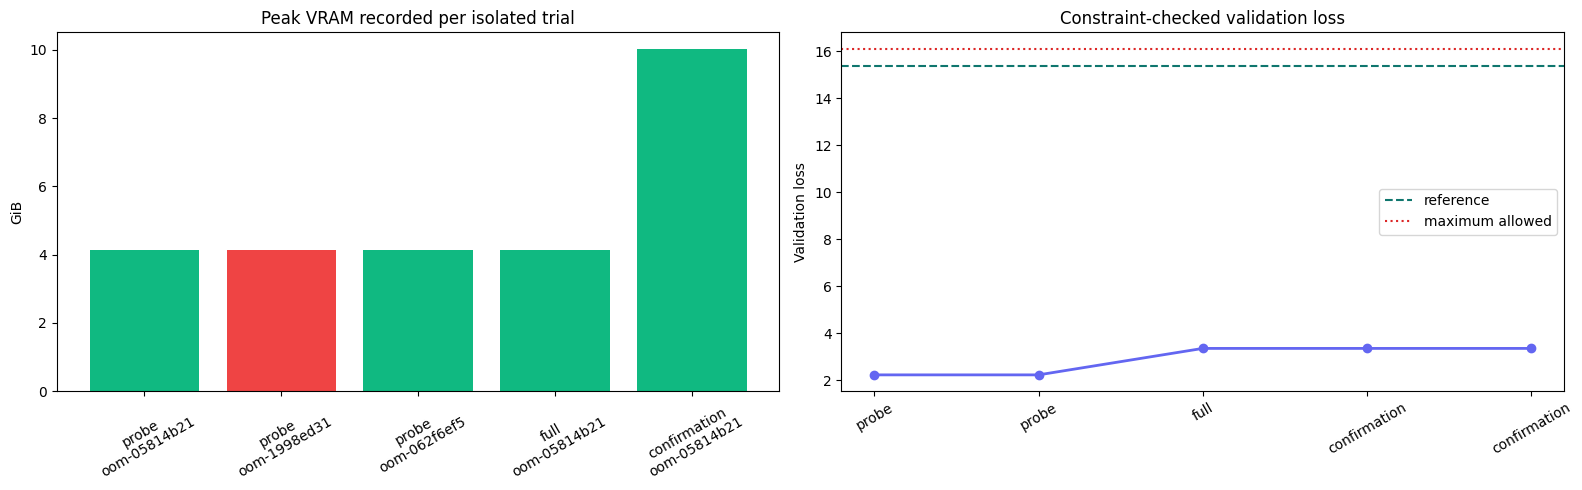

In [17]:
if not trials_frame.empty:
    labels = [
        f"{phase}\n{candidate[:12]}"
        for phase, candidate in zip(
            trials_frame["phase"], trials_frame["candidate"]
        )
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(
        labels,
        trials_frame["peak_vram_gib"].fillna(0),
        color=[
            "#ef4444" if status != "success" else "#10b981"
            for status in trials_frame["status"]
        ],
    )
    axes[0].set_title("Peak VRAM recorded per isolated trial")
    axes[0].set_ylabel("GiB")
    axes[0].tick_params(axis="x", rotation=30)

    metric_frame = trials_frame.dropna(subset=["validation_loss"])
    axes[1].plot(
        range(len(metric_frame)),
        metric_frame["validation_loss"],
        marker="o",
        linewidth=2,
        color="#6366f1",
    )
    axes[1].axhline(
        REFERENCE_VALIDATION_LOSS,
        linestyle="--",
        color="#0f766e",
        label="reference",
    )
    axes[1].axhline(
        REFERENCE_VALIDATION_LOSS + 0.75,
        linestyle=":",
        color="#dc2626",
        label="maximum allowed",
    )
    axes[1].set_xticks(
        range(len(metric_frame)),
        metric_frame["phase"],
        rotation=30,
    )
    axes[1].set_title("Constraint-checked validation loss")
    axes[1].set_ylabel("Validation loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 10. Inspect ranking and independent verification

Ranking is provisional evidence, not the verdict. The verification report is the only
component allowed to declare recovery.

In [18]:
print("Provisional ranking:")
display(JSON(campaign.get("ranking"), expanded=False))

print("Independent verification reports:")
display(JSON(campaign.get("verifications"), expanded=True))

assert result.verified, (
    "The campaign did not verify a recovery. Inspect the trial table and verifier "
    "report above before changing the contract."
)
assert campaign["status"] == "verified"
assert campaign["stopped_reason"] == "verified_recovery"
assert len(result.verified_run_ids) == 2
assert all(
    trial["phase"] == "confirmation"
    for trial in campaign["trials"]
    if trial["run_id"] in result.verified_run_ids
)

source_row = storage.get_run(FAILED_RUN_ID)
assert bool(source_row["resolved"]) is True
assert "Verified by recovery campaign" in source_row["resolved_note"]

print("✓ Genuine CUDA OOM captured")
print("✓ Deterministic failure capsule persisted")
print("✓ Recovery plan sealed before compute")
print("✓ Trials ran under distinct subprocess identities")
print("✓ Metric and progress constraints passed")
print("✓ Two confirmation runs independently verified the candidate")
print("✓ Source OOM was resolved only by verifier-backed evidence")

Provisional ranking:


<IPython.core.display.JSON object>

Independent verification reports:


<IPython.core.display.JSON object>

✓ Genuine CUDA OOM captured
✓ Deterministic failure capsule persisted
✓ Recovery plan sealed before compute
✓ Trials ran under distinct subprocess identities
✓ Metric and progress constraints passed
✓ Two confirmation runs independently verified the candidate
✓ Source OOM was resolved only by verifier-backed evidence


## 11. Inspect the complete audit trail through the CLI

These commands work in Colab without the local web UI. JSON mode is useful for CI and
downstream automation.

In [19]:
commands = [
    ["watcher", "--data-dir", str(STORAGE_ROOT), "runs", "--project", "colab-real-oom"],
    ["watcher", "--data-dir", str(STORAGE_ROOT), "failures", "--project", "colab-real-oom"],
    ["watcher", "--data-dir", str(STORAGE_ROOT), "recoveries", "--project", "colab-real-oom"],
    ["watcher", "--data-dir", str(STORAGE_ROOT), "recovery", result.campaign_id],
]

for command in commands:
    print("\n$", " ".join(command))
    subprocess.run(command, check=True)


$ watcher --data-dir /content/watcherml-real-oom-demo/.watcherml runs --project colab-real-oom

$ watcher --data-dir /content/watcherml-real-oom-demo/.watcherml failures --project colab-real-oom

$ watcher --data-dir /content/watcherml-real-oom-demo/.watcherml recoveries --project colab-real-oom

$ watcher --data-dir /content/watcherml-real-oom-demo/.watcherml recovery colab-real-oom-campaign


## 12. Export artifacts for download

Download the failed-run capsule, sealed plan, verifier-backed result, and SQLite database
before the Colab runtime is deleted.

In [20]:
EXPORT_PATH = PROJECT_ROOT / "failed-run-capsule.zip"

subprocess.run(
    [
        "watcher",
        "--data-dir",
        str(STORAGE_ROOT),
        "export",
        FAILED_RUN_ID,
        "--out",
        str(EXPORT_PATH),
    ],
    check=True,
)

print("Downloadable artifacts:")
for path in (
    EXPORT_PATH,
    PLAN_PATH,
    RESULT_PATH,
    STORAGE_ROOT / "watcher.db",
):
    print(" -", path, f"({path.stat().st_size / 1024:.1f} KiB)")

# Uncomment to download selected artifacts through the browser.
# from google.colab import files
# files.download(str(EXPORT_PATH))
# files.download(str(PLAN_PATH))
# files.download(str(RESULT_PATH))

Downloadable artifacts:
 - /content/watcherml-real-oom-demo/failed-run-capsule.zip (10.6 KiB)
 - /content/watcherml-real-oom-demo/recovery-plan.json (7.8 KiB)
 - /content/watcherml-real-oom-demo/recovery-result.json (24.7 KiB)
 - /content/watcherml-real-oom-demo/.watcherml/watcher.db (4.0 KiB)


## What this notebook proved

WatcherML preserved the original failure, sealed the acceptable intervention and compute
space, executed bounded candidates in fresh processes, rejected infeasible outcomes,
ranked only constraint-satisfying full trials, and required repeated independent evidence
before changing the failed run's resolution state.

For your final pre-release validation, save the output of this notebook and attach the
exported recovery result to the `v0.1.0` release notes as evidence that WatcherML works on
a real NVIDIA GPU.

In [21]:
!watcher recoveries

OOM recovery campaigns
CAMPAIGN                  PROJECT          STATUS     VERIFIED   REASON              STARTED         
───────────────────────   ──────────────   ────────   ────────   ─────────────────   ────────────────
colab-real-oom-campaign   colab-real-oom   verified   yes        verified_recovery   2026-08-14 06:31


In [22]:
!watcher recovery colab-real-oom-campaign

Recovery campaign colab-real-oom-campaign
project      colab-real-oom
source run   colab-real-oom-9373d9
status       verified
verified     yes
reason       verified_recovery
candidate    oom-05814b21696fe38a9ae8
trial budget  [████████████████████████] 6/6

Trials
PHASE          RUN ID                         CANDIDATE                  STATUS            PROGRESS   VERIFIED
────────────   ────────────────────────────   ────────────────────────   ───────────────   ────────   ────────
probe          run-561212422b9c42dc99d113c9   oom-05814b21696fe38a9ae8   success           2          no      
probe          run-b75b5aaa5ab446a2ccb3963e   oom-1998ed31441cc96ed210   training_failed   —          no      
probe          run-3d26ff2e023ed2f182c27665   oom-062f6ef5e77dcdc05a6c   success           2          no      
full           run-ff16c22feca458375042acb7   oom-05814b21696fe38a9ae8   success           6          no      
confirmation   run-90bf1626350ff1448566a045   oom-05814b21696fe38a9a

In [23]:
import shutil

shutil.make_archive(
    "/content/watcherml-real-oom-evidence",
    "zip",
    "/content/watcherml-real-oom-demo/.watcherml",
)

'/content/watcherml-real-oom-evidence.zip'